In [1]:
import librosa
import librosa.display
import scipy as sp
import IPython.display as ipd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
audio_path = "../audio/piano_c.wav"
ipd.Audio(audio_path)

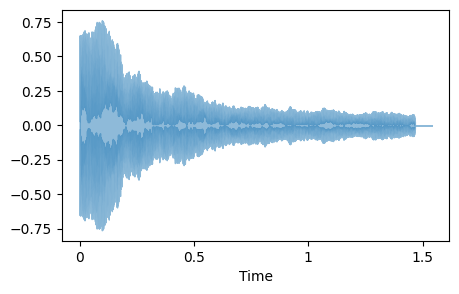

In [7]:
# signal, sampling rate
signal, sr = librosa.load(audio_path)
plt.figure(figsize=(5,3))
librosa.display.waveshow(signal, sr=sr, alpha=0.5)
plt.show()

In [8]:
ft = sp.fft.fft(signal)
magnitude = np.absolute(ft)
frequency = np.linspace(0, sr, len(magnitude))

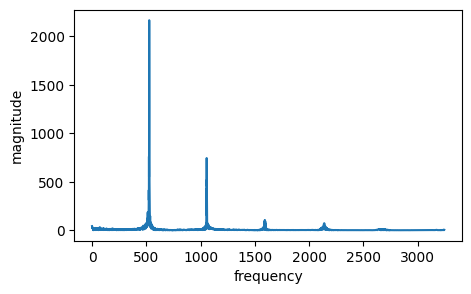

In [10]:
plt.figure(figsize=(5, 3))
plt.plot(frequency[:5000], magnitude[:5000])
plt.xlabel("frequency")
plt.ylabel("magnitude")
plt.show()

In [12]:
len(signal), sr

(33968, 22050)

In [ ]:
# each sample duration
d = 1 / sr
d

4.5351473922902495e-05

In [14]:
# duration of 523 frequency
d_523 = 1 / 523
d_523

0.0019120458891013384

In [16]:
# duration of 400 samples is 0.02
d_400_samples = 400 * d
d_400_samples

0.018140589569160998

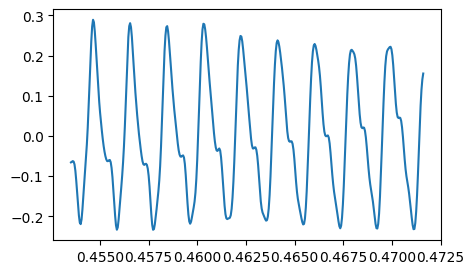

In [22]:
# 10000 ~ 10400 samples
samples = range(len(signal))
t = librosa.samples_to_time(samples, sr=sr)

plt.figure(figsize=(5, 3))
plt.plot(t[10000:10400], signal[10000:10400])
plt.show()

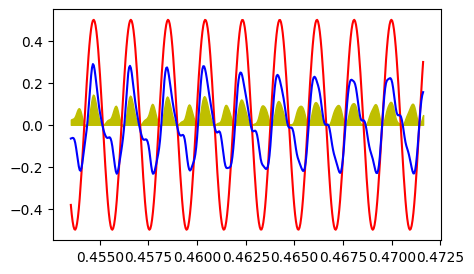

In [36]:
f = 523
phase = 0.55
phase2 = 1.5
sin = 0.5 * np.sin(2*np.pi * (f*t-phase))
sin2 =  0.5 * np.sin(2*np.pi * (f*t-phase2))
plt.figure(figsize=(5, 3))
plt.plot(t[10000:10400], sin[10000:10400], color="r")
# plt.plot(t[10000:10400], sin2[10000:10400], color="y")
plt.plot(t[10000:10400], signal[10000:10400], color="b")

# similarity of f_523 and C wave
plt.fill_between(t[10000:10400], sin[10000:10400] * signal[10000:10400], color="y")
plt.show()

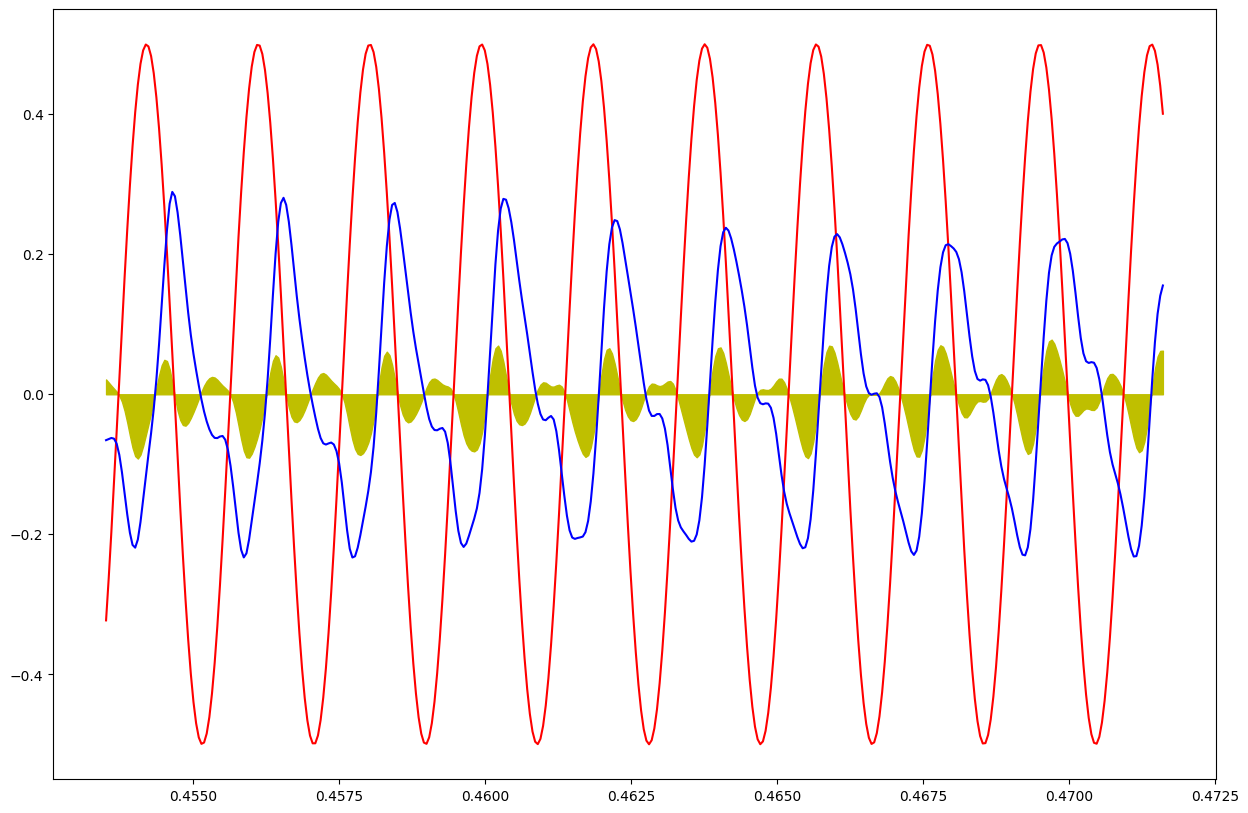

In [41]:
# If change the phase 0.55 to 0.00, 0.2
f = 523
phase = 0.3
phase2 = 1.5
sin = 0.5 * np.sin(2*np.pi * (f*t-phase))
sin2 =  0.5 * np.sin(2*np.pi * (f*t-phase2))
plt.figure(figsize=(15, 10))
plt.plot(t[10000:10400], sin[10000:10400], color="r")
# plt.plot(t[10000:10400], sin2[10000:10400], color="y")
plt.plot(t[10000:10400], signal[10000:10400], color="b")

# similarity of f_523 and C wave
plt.fill_between(t[10000:10400], sin[10000:10400] * signal[10000:10400], color="y")
plt.show()

### step
-  choose a frequency
-  optimise phase
-  calculate magnitude

in all frequency

https://teropa.info/harmonics-explorer/